In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

banking = pd.read_csv('C:\\DS_AI\\Assignment7\\banking_churn_prediction.csv')
banking.head(5)
banking.shape
banking.info()
banking.describe()
banking.isnull().sum()

print("\nDuplicate Rows:", banking.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  str    
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  str    
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  28382 non-n

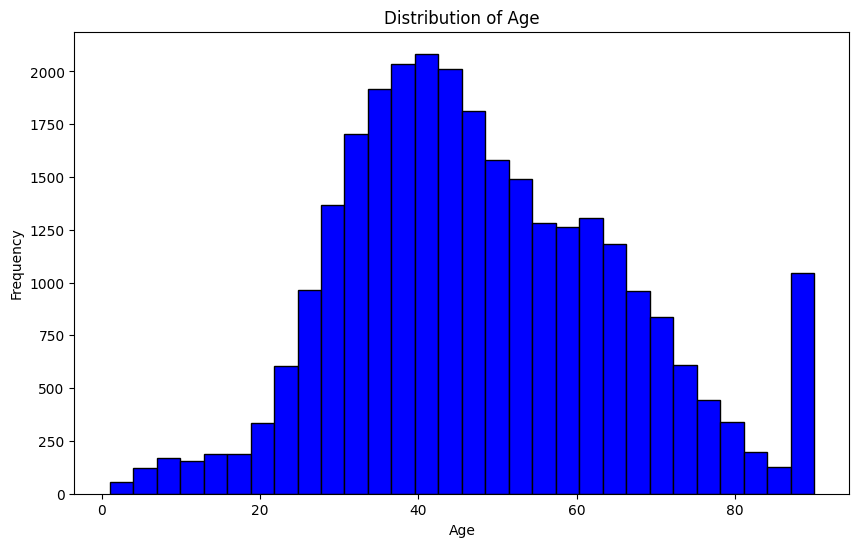

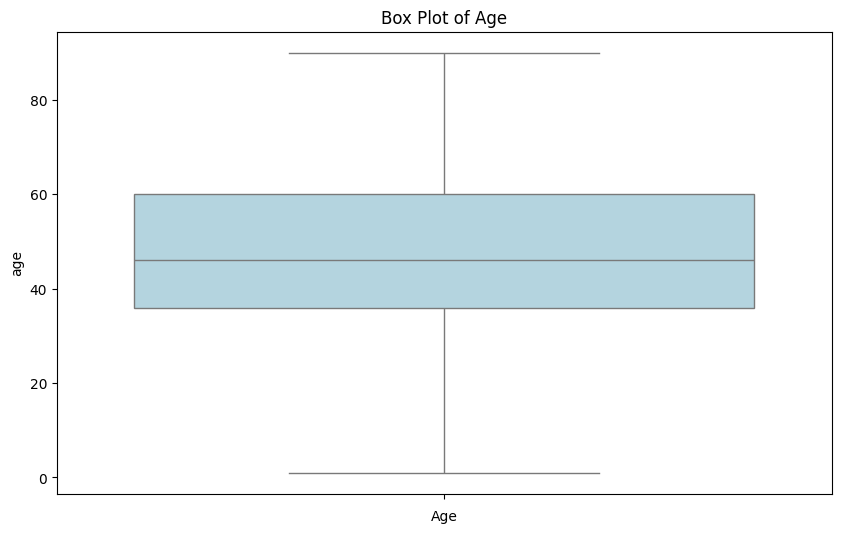

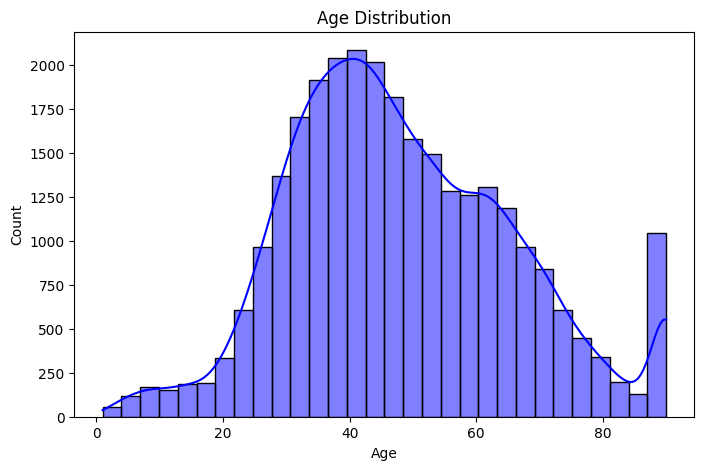

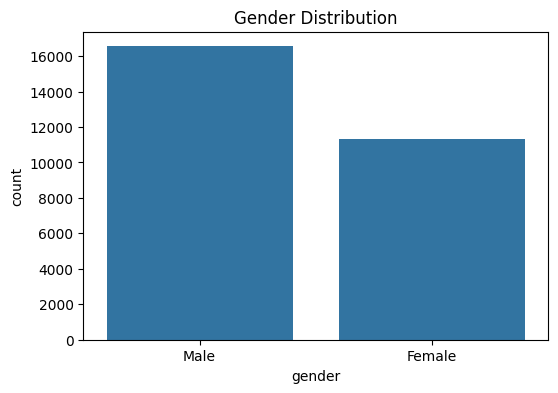

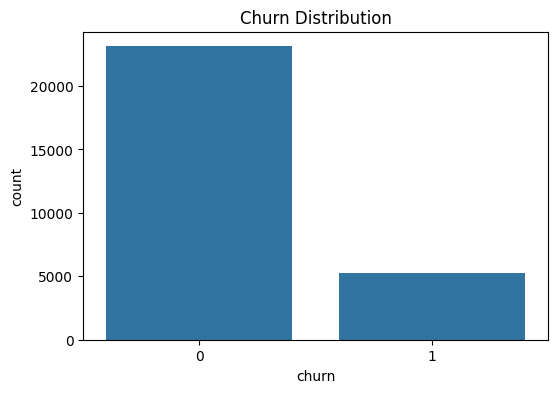

In [ ]:
### Univariate Analysis
plt.figure(figsize=(10, 6))
plt.hist(banking['age'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')   
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(banking['age'], color='lightblue')
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(banking['age'], bins=30, kde=True, color='blue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=banking)
plt.title("Gender Distribution")
plt.show()

# Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=banking)
plt.title("Churn Distribution")
plt.show()

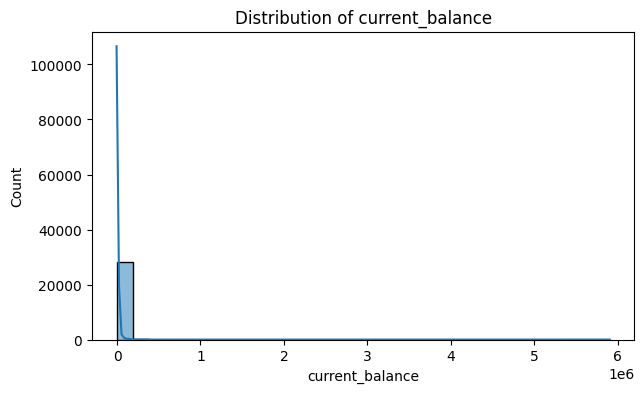

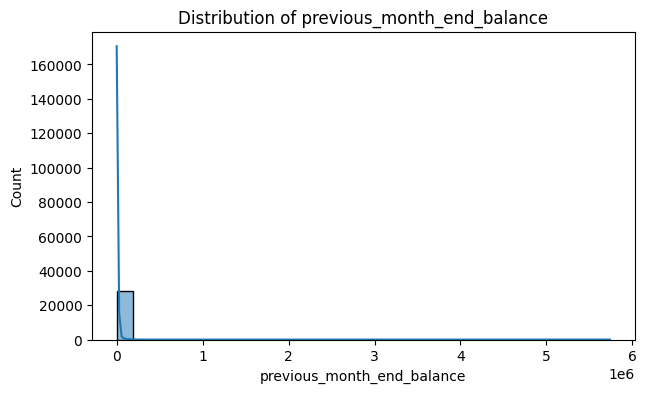

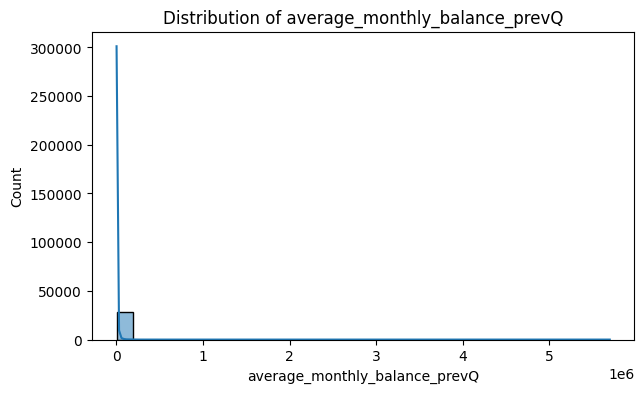

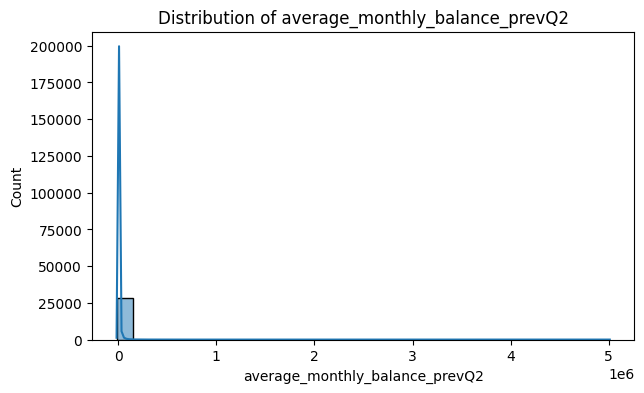

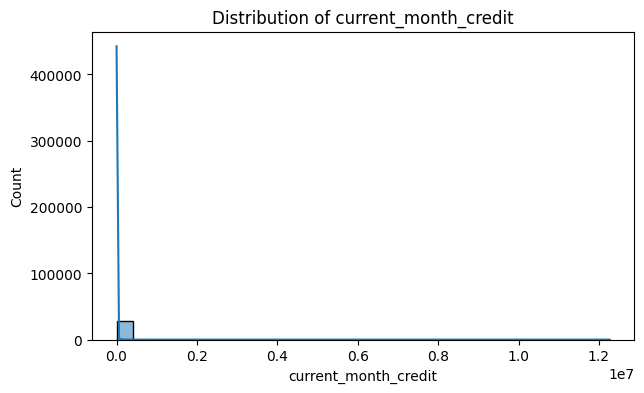

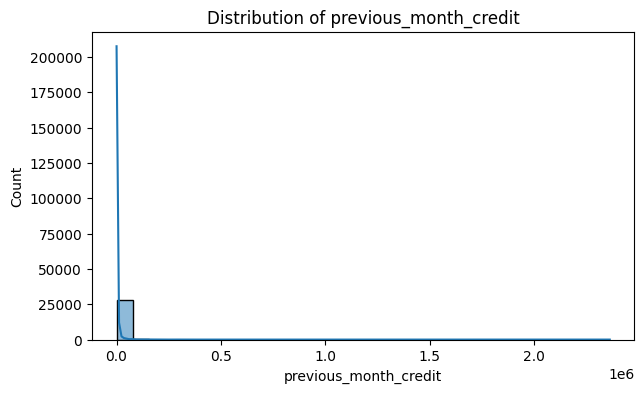

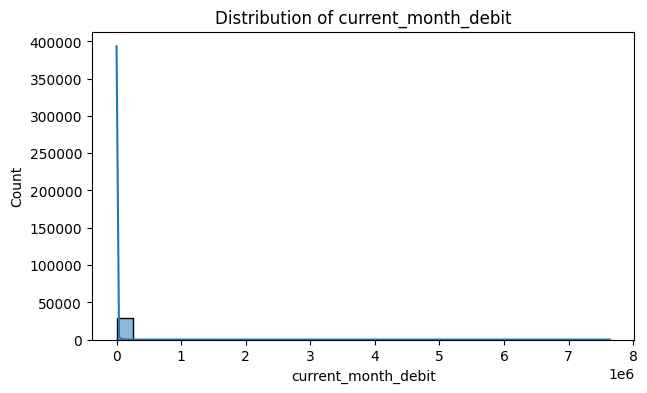

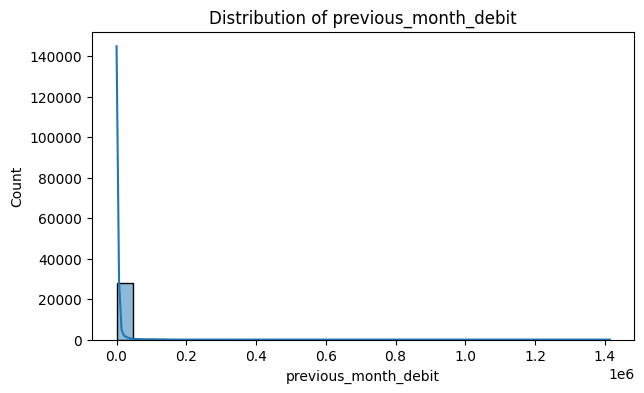

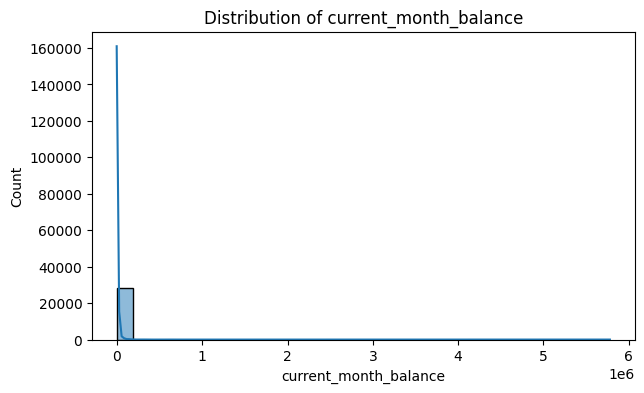

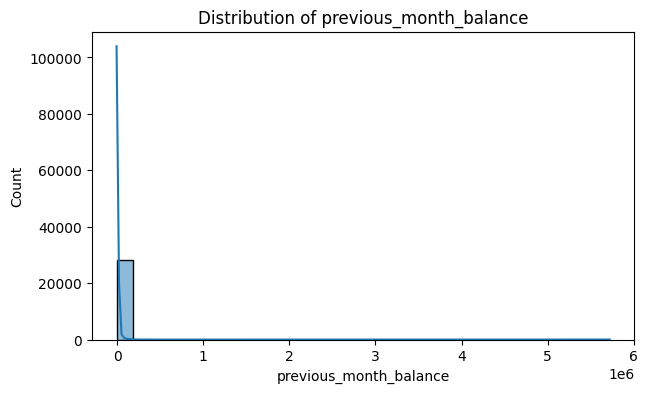

In [8]:
### cNumerical Feature Distributions

numerical_cols = [
    'current_balance',
    'previous_month_end_balance',
    'average_monthly_balance_prevQ',
    'average_monthly_balance_prevQ2',
    'current_month_credit',
    'previous_month_credit',
    'current_month_debit',
    'previous_month_debit',
    'current_month_balance',
    'previous_month_balance'
]

for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(banking[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()


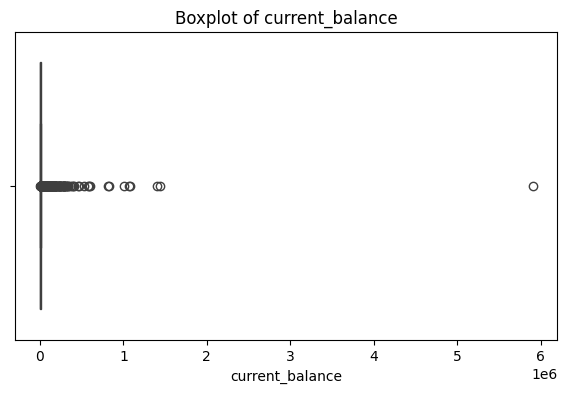

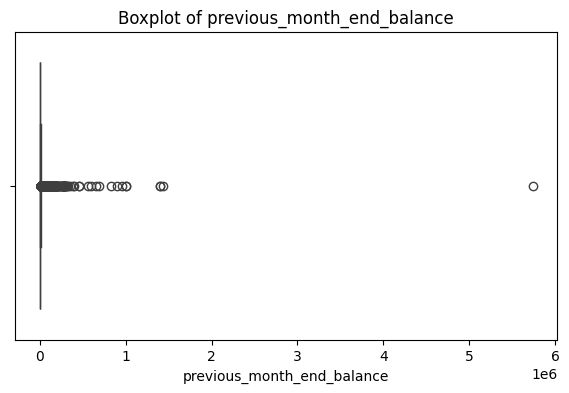

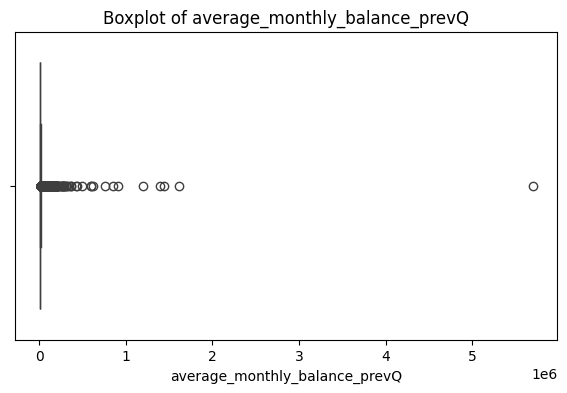

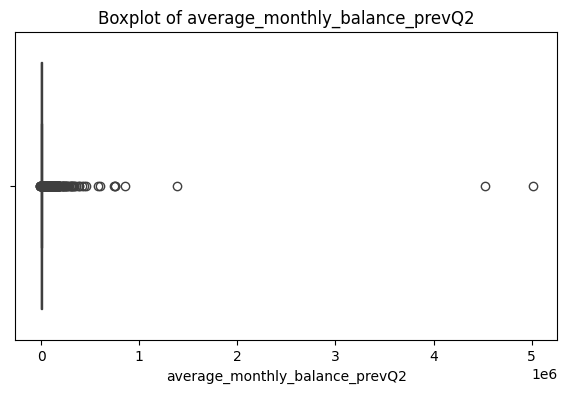

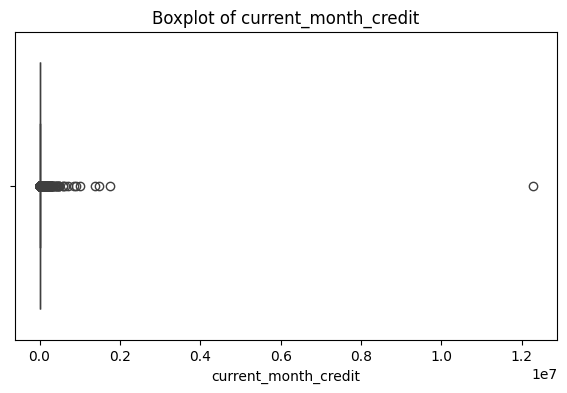

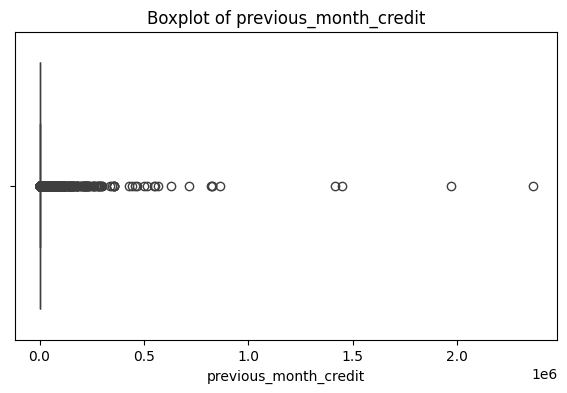

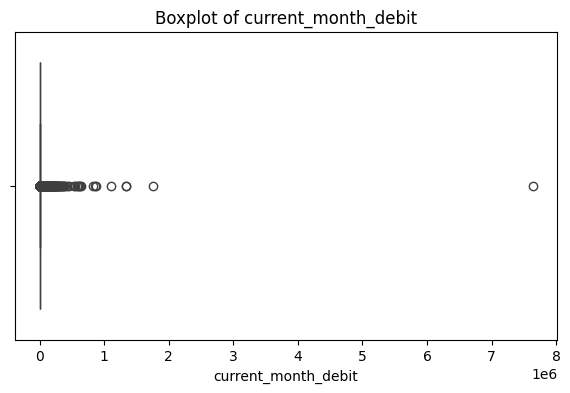

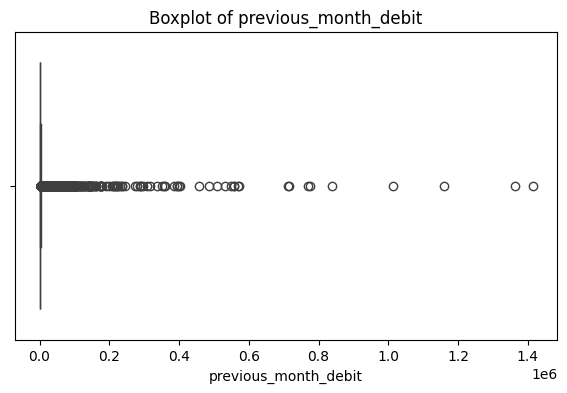

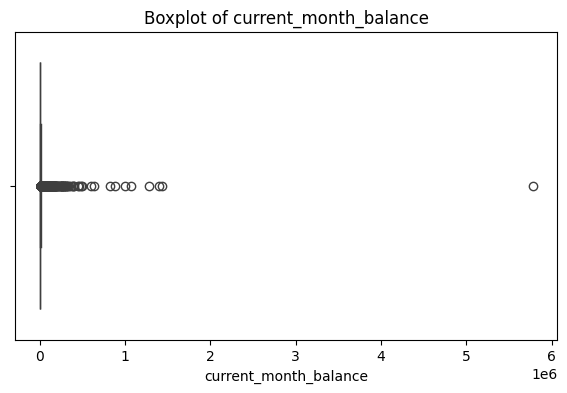

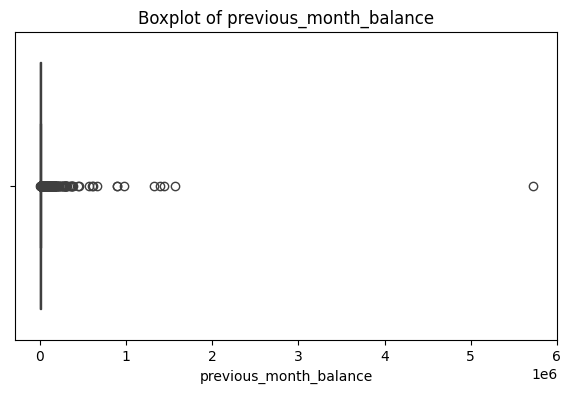

In [9]:
### Outlier Detection using Boxplots
for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=banking[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

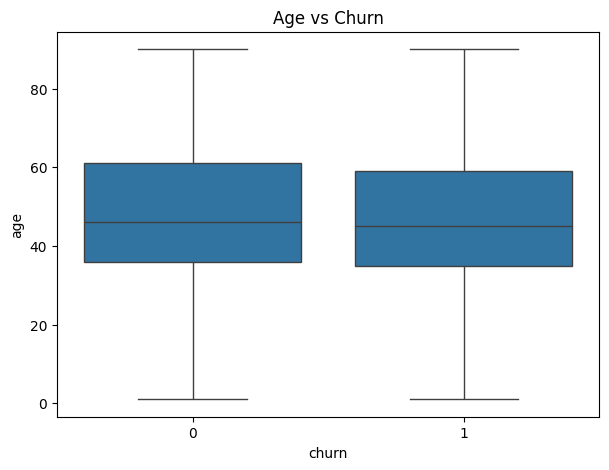

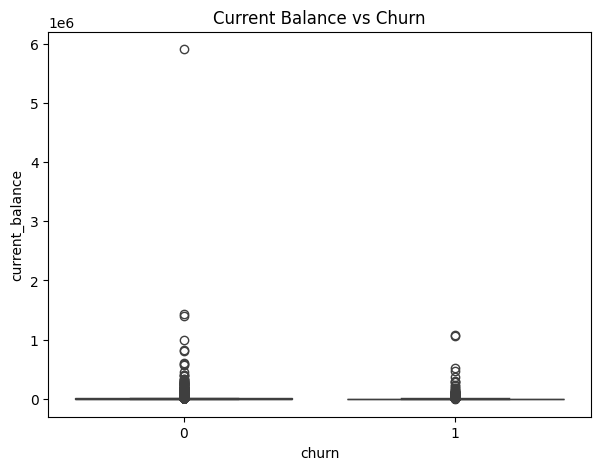

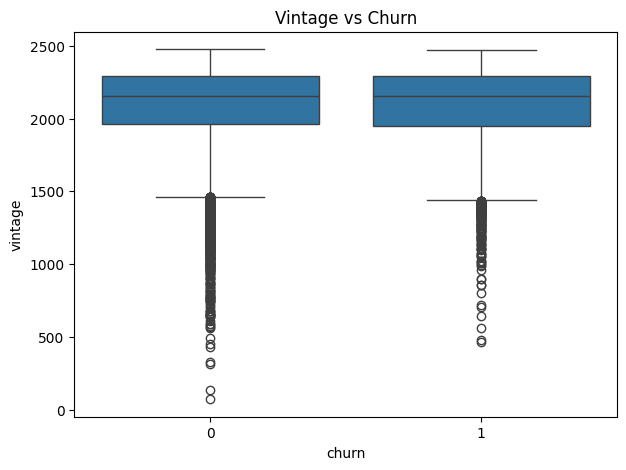

In [10]:
###  Bivariate Analysis

# Age vs Churn
plt.figure(figsize=(7,5))
sns.boxplot(x='churn', y='age', data=banking)
plt.title("Age vs Churn")
plt.show()

# Current Balance vs Churn
plt.figure(figsize=(7,5))
sns.boxplot(x='churn', y='current_balance', data=banking)
plt.title("Current Balance vs Churn")
plt.show()

# Vintage vs Churn
plt.figure(figsize=(7,5))
sns.boxplot(x='churn', y='vintage', data=banking)
plt.title("Vintage vs Churn")
plt.show()

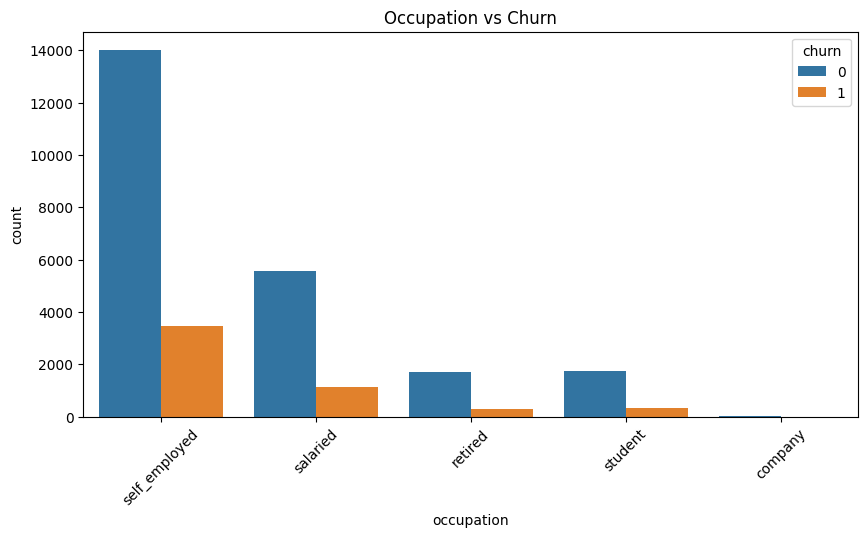

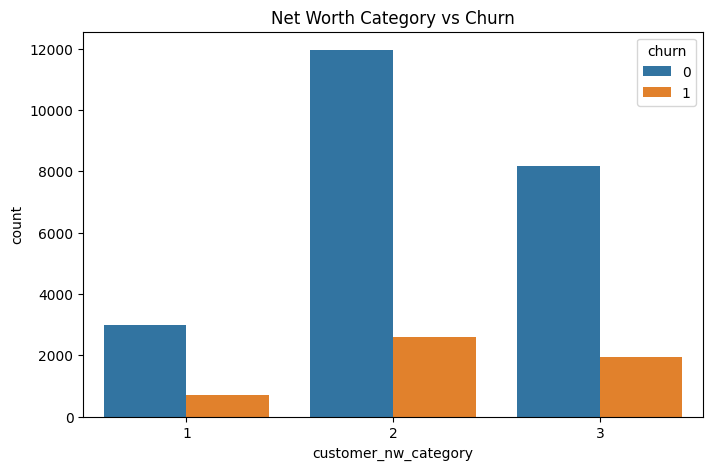

In [11]:
### Categorical Analysis
# ---------------------------------------------------------

# Occupation vs Churn
plt.figure(figsize=(10,5))
sns.countplot(x='occupation', hue='churn', data=banking)
plt.xticks(rotation=45)
plt.title("Occupation vs Churn")
plt.show()

# Net Worth Category vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='customer_nw_category', hue='churn', data=banking)
plt.title("Net Worth Category vs Churn")
plt.show()

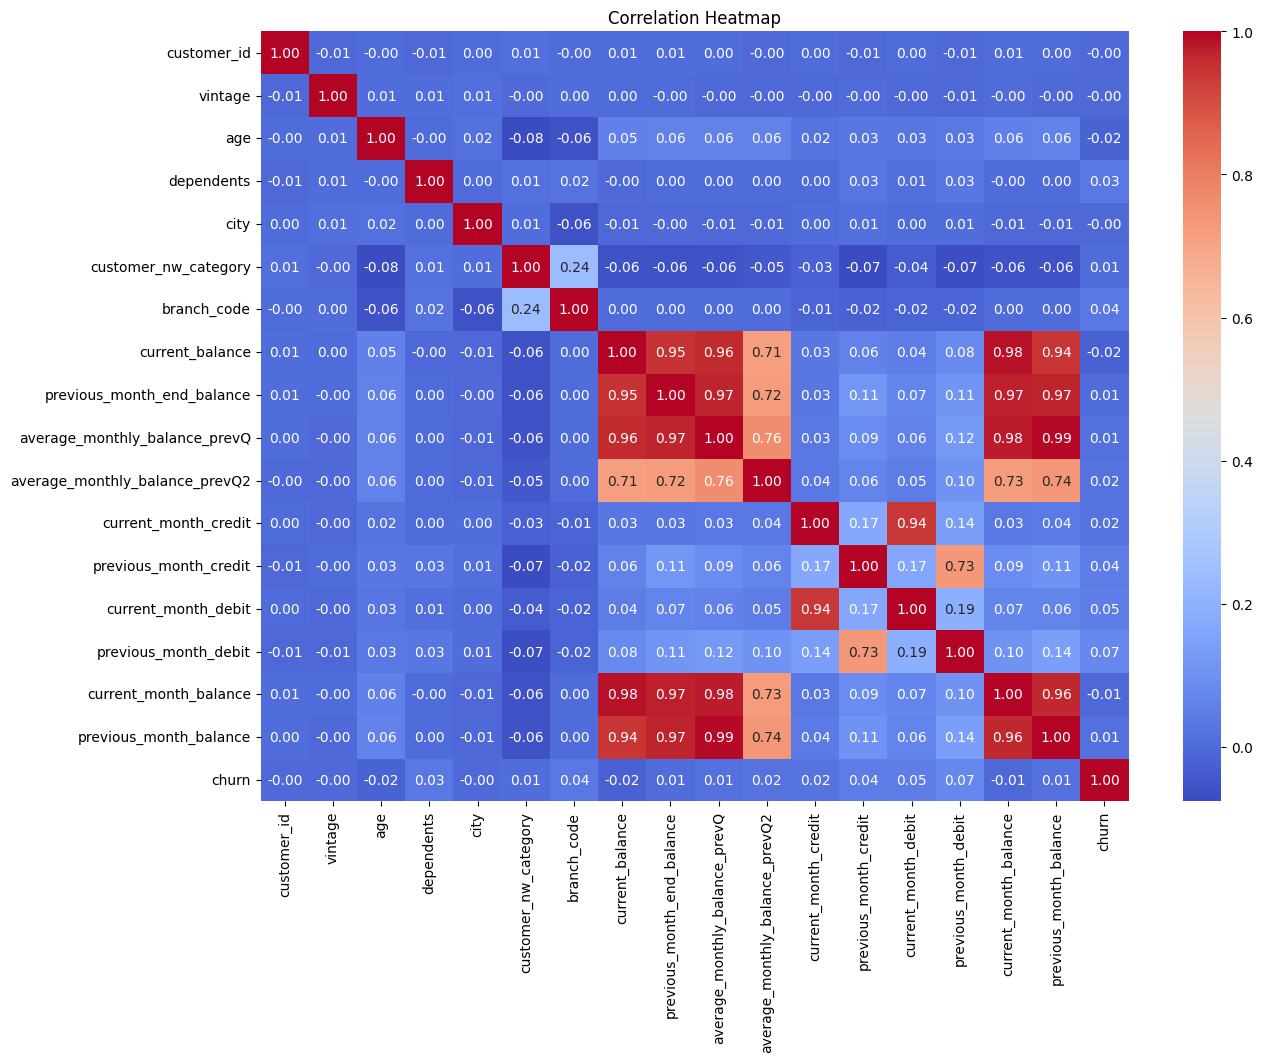

In [12]:
### Correlation Heatmap

plt.figure(figsize=(14,10))

correlation = banking.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

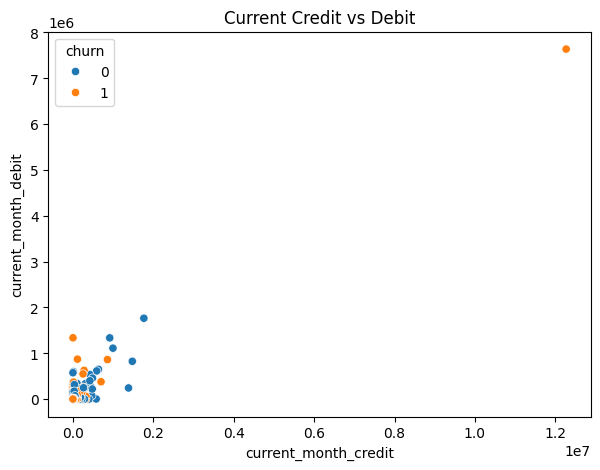

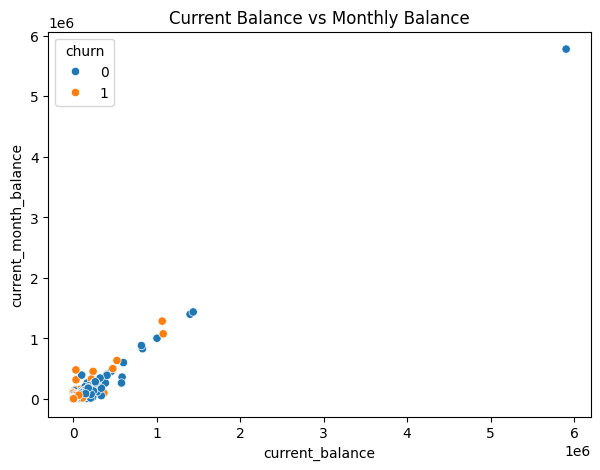

In [13]:
### Scatterplots

# Credit vs Debit
plt.figure(figsize=(7,5))
sns.scatterplot(x='current_month_credit',
                y='current_month_debit',
                hue='churn',
                data=banking)

plt.title("Current Credit vs Debit")
plt.show()

# Balance Comparison
plt.figure(figsize=(7,5))
sns.scatterplot(x='current_balance',
                y='current_month_balance',
                hue='churn',
                data=banking)

plt.title("Current Balance vs Monthly Balance")
plt.show()


In [ ]:
### Churn Percentage

churn_rate = banking['churn'].value_counts(normalize=True) * 100

print("\nChurn Percentage:")
print(churn_rate)


Churn Percentage:
churn
0    81.467127
1    18.532873
Name: proportion, dtype: float64


: 